# Set WD to Root

In [1]:
from pathlib import Path
import os

repo_root = Path.cwd().parents[0]
os.chdir(repo_root)

# print(Path.cwd())

# Load Model and Hyperparameters

In [14]:
import json

# 加载超参
PARAM_PATH = Path('./config/test_transformer_params.json')

with open(PARAM_PATH, "r", encoding="utf-8") as f:
    params = json.load(f)

print(params)


{'batch_size': 200, 'learning_rate': 0.01, 'epochs': 5000, 'embedding_dim': 100, 'num_heads': 4, 'num_layers': 3}


# Load Data and Tokenizer

In [15]:
from scripts.data_loader.piqa_dataloader import get_piqa_dataloaders
from pathlib import Path
import sentencepiece as spm

BASE_PATH = Path('./datasets/PIQA')
BASE_PATH = BASE_PATH.resolve()

tokenizer = spm.SentencePieceProcessor(
    model_file="./scripts/tokenizer/piqa_bpe_v2.model"
)

train_loader, validate_loader, test_loader = get_piqa_dataloaders(base_path=BASE_PATH,
                                                                  tokenizer=tokenizer,
                                                                  batch_size=params['batch_size'])

In [16]:
from scripts.models.transformer_bi_classifier import TransformerClassifier
import torch.optim as optim
import torch.nn.functional as F

# 初始化模型和优化器
tf_model = TransformerClassifier(vocab_size=tokenizer.vocab_size(),
                                 embedding_dim=params['embedding_dim'],
                                 padding_idx=tokenizer.pad_id(),
                                 max_seq_length=2048,   # 设为 2048 防止序列长度溢出
                                 num_heads=params['num_heads'],
                                 num_layers=params['num_layers'])

tf_optimiser = optim.SGD(params=tf_model.parameters(), lr=params['learning_rate'])
criterion = F.cross_entropy

# 训练循环

Batch size 不要超过 200，否则很容易内存溢出！

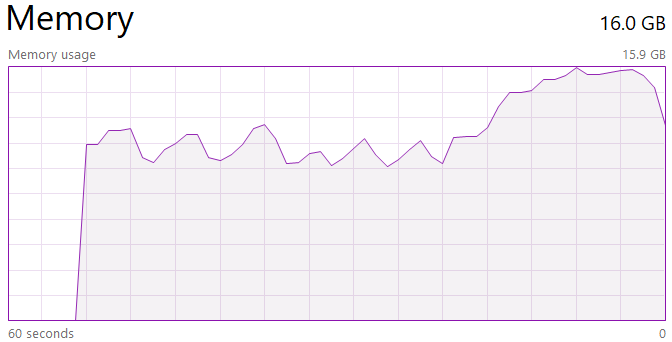

In [17]:
from time import perf_counter

tf_model.train()

epoch_loss = 0.0

for input_1, input_2, mask_1, mask_2, labels in train_loader:

    start_ts = perf_counter()
    # Forward
    tf_optimiser.zero_grad()

    logits = tf_model.forward(input_1, input_2, mask_1, mask_2)

    # Loss
    loss = criterion(
        input=logits,
        target=labels
    )

    # Backward
    loss.backward()

    tf_optimiser.step()

    # Record loss
    epoch_loss += loss.item()

    end_ts = perf_counter()
    time_elips = end_ts - start_ts
    
    print(
        f"time={time_elips:.2f}, "
        f"loss={loss.item():.2f}"
    )


time=6.82, loss=0.70
time=7.64, loss=0.71
time=9.92, loss=0.69
time=11.51, loss=0.71


KeyboardInterrupt: 

# 取出注意力矩阵 Weight

In [ ]:
# 取出注意力投影矩阵
W_Q, W_K, W_V = attn.in_proj_weight.chunk(3, dim=0)

print(W_Q.shape)
print(W_K.shape)
print(W_V.shape)

# torch.Size([100, 100])
# torch.Size([100, 100])
# torch.Size([100, 100])

# 如何自己拆成多头注意力？？

torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])


In [15]:
layer = tf_model.encoder.layers[0]

attn = layer.self_attn

print(attn)

MultiheadAttention(
  (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
)


In [16]:
def extract_encoder_attentions(
    model,
    ids,
    mask
):
    x = model.embedding(ids)
    x = model.position_embedding(x)

    padding_mask = ~mask

    attentions = []

    for layer in model.encoder.layers:

        # ---- Self Attention ----
        attn_output, attn_weights = layer.self_attn(
            x,
            x,
            x,
            key_padding_mask=padding_mask,
            need_weights=True,
            average_attn_weights=False
        )

        # 保存 attention
        attentions.append(attn_weights.detach())

        # ---- Residual + LayerNorm ----
        x = layer.norm1(
            x + layer.dropout1(attn_output)
        )

        # ---- Feed Forward ----
        ff_output = layer.linear2(
            layer.dropout(
                layer.activation(
                    layer.linear1(x)
                )
            )
        )

        # ---- Residual + LayerNorm ----
        x = layer.norm2(
            x + layer.dropout2(ff_output)
        )

    return attentions

In [17]:
attentions = extract_encoder_attentions(
    tf_model,
    goal_ids,
    goal_mask
)

In [18]:
print(attentions[0].shape)
print(attentions[1].shape)

torch.Size([200, 4, 26, 26])
torch.Size([200, 4, 26, 26])
